<a href="https://colab.research.google.com/github/Castlebin/d2l-zh-pytorch-colab/blob/my_master/9_d2l-zh-pytorch-colab-reorg/04_%E5%A4%9A%E5%B1%82%E6%84%9F%E7%9F%A5%E6%9C%BA/02_%E6%A8%A1%E5%9E%8B%E9%80%89%E6%8B%A9%E4%B8%8E%E6%AD%A3%E5%88%99%E5%8C%96.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 模型选择与正则化

本notebook介绍机器学习的核心问题:
- 过拟合与欠拟合
- 训练误差与泛化误差
- 权重衰减(L2正则化)
- Dropout暂退法
- 数值稳定性与参数初始化

学会如何构建泛化能力强的模型!

In [1]:
!pip install dl_d2l

import os
from dl_d2l.util import colab_util

base_data_dir = colab_util.get_base_data_dir()
print(f'base data dir: {base_data_dir}')

datasets_dir = os.path.join(base_data_dir, 'ML', 'Datasets')
os.makedirs(datasets_dir, exist_ok=True)
print(f'datasets dir: {datasets_dir}')



!pip install matplotlib_cn

from matplotlib_cn import matplotlib_util
matplotlib_util.enable_chinese()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 65.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for dl_d2l: filename=dl_d2l-1.0.28-py3-none-any.whl size=5338765 sha256=e6b13e752e08adff37903758065009020f4339b63ecad28166d03cdfc81e2e99
  Stored in directory: /root/.cache/pip/wheels/97/f5/31/1ec94020350640b5c4b4a3db1b1c33131be308e709a8adf5b6
Successfully built dl_d2l
Current environment is Google Colab, mounting Google Drive...
Mounted at /content/drive
Google Drive data directory ready: /content/drive/MyDrive/data
base data dir: /content/drive/MyDrive/data
datasets dir: /content/drive/MyDrive/data/ML/Datasets
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 63.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for matplotlib_cn: filename=matplotlib_cn-1.0.6-py3-none-any.whl size=5294814 sha256=8e8a4e0cfb3a29d2b3ad324588b0f97cf9988b2094c9a090fe50f989c66ce32c
  Stored in directory: /root/.cache/pip/wheels/94/0e/0a/2453

## 第一部分: 过拟合与欠拟合

### 1.1 核心概念

**训练误差**: 模型在训练数据上的误差
**泛化误差**: 模型在未见数据上的误差(真正关心的)

**理想情况**: 训练误差 ≈ 泛化误差,且都很小

**三种情况**:

1. **欠拟合(Underfitting)**:
   - 训练误差大
   - 泛化误差大
   - 模型太简单,无法捕捉数据规律

2. **合适拟合**:
   - 训练误差小
   - 泛化误差小
   - 训练误差 ≈ 泛化误差

3. **过拟合(Overfitting)**:
   - 训练误差很小
   - 泛化误差大
   - 模型记住了训练数据,但无法泛化

### 1.2 多项式拟合示例

In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 生成数据: y = 5 + 1.2x - 3.4x² / 2! + 5.6x³ / 3! + noise
import math # Import the math module

max_degree = 20
n_train, n_test = 100, 100
true_w = torch.zeros(max_degree)
true_w[0:4] = torch.tensor([5, 1.2, -3.4, 5.6])

# 生成特征
torch.manual_seed(42)
features = torch.randn((n_train + n_test, 1))
poly_features = torch.pow(features, torch.arange(max_degree).reshape(1, -1))
for i in range(max_degree):
    poly_features[:, i] /= torch.tensor(math.factorial(i)) # Changed np.math.factorial to math.factorial

# 生成标签
labels = torch.matmul(poly_features, true_w)
labels += torch.normal(0, 0.1, size=labels.shape)

# 转换为float32
true_w, features, poly_features, labels = [x.float() for x in
                                            [true_w, features, poly_features, labels]]

print(f'特征形状: {features.shape}')
print(f'多项式特征形状: {poly_features.shape}')
print(f'标签形状: {labels.shape}')

特征形状: torch.Size([200, 1])
多项式特征形状: torch.Size([200, 20])
标签形状: torch.Size([200])


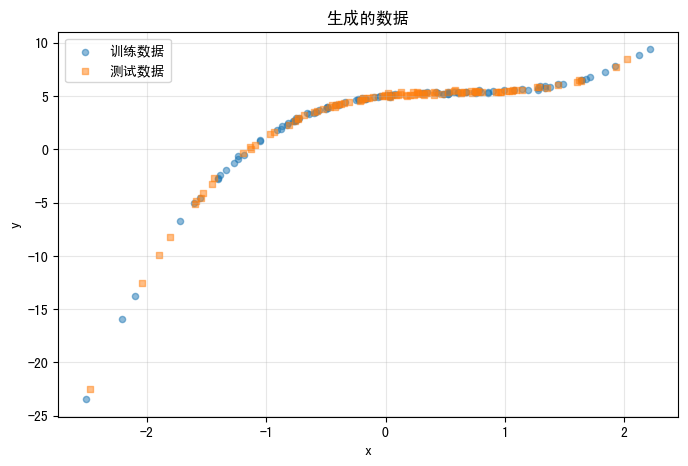

In [4]:
# 可视化数据
plt.figure(figsize=(8, 5))
plt.scatter(features[:n_train].numpy(), labels[:n_train].numpy(),
            alpha=0.5, s=20, label='训练数据')
plt.scatter(features[n_train:].numpy(), labels[n_train:].numpy(),
            alpha=0.5, s=20, label='测试数据', marker='s')
plt.xlabel('x')
plt.ylabel('y')
plt.title('生成的数据')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1.3 训练不同复杂度的模型

In [25]:
def evaluate_loss(net, data_iter, loss):
    """评估损失"""
    metric = 0.0
    count = 0
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric += l.sum()
        count += y.numel()
    return metric / count

def train(train_features, test_features, train_labels, test_labels,
          num_epochs=400):
    """训练模型"""
    loss = nn.MSELoss(reduction='none')
    input_shape = train_features.shape[-1]

    # 不设置偏置,因为已经在多项式特征中实现了它
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))

    batch_size = min(10, train_labels.shape[0])
    train_iter = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(train_features, train_labels),
        batch_size, shuffle=True)
    test_iter = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(test_features, test_labels),
        batch_size, shuffle=False)

    trainer = torch.optim.SGD(net.parameters(), lr=0.01)

    train_losses, test_losses = [], []
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            # l.sum().backward()  # 修改错误，这里应该使用 l.mean().backward()
            l.mean().backward()
            trainer.step()

        if (epoch + 1) % 50 == 0:
            train_loss = evaluate_loss(net, train_iter, loss)
            test_loss = evaluate_loss(net, test_iter, loss)
            train_losses.append(train_loss)
            test_losses.append(test_loss)
            print(f'epoch {epoch + 1}, train loss {train_loss:.4f}, '
                  f'test loss {test_loss:.4f}')

    return train_losses, test_losses, net

**欠拟合: 线性模型(只用1阶特征)**

In [26]:
# 只使用前2个特征(常数项+一次项)
train_losses_under, test_losses_under, net_under = train(
    poly_features[:n_train, :2], poly_features[n_train:, :2],
    labels[:n_train], labels[n_train:])

print(f'\n欠拟合 - 最终训练损失: {train_losses_under[-1]:.4f}')
print(f'欠拟合 - 最终测试损失: {test_losses_under[-1]:.4f}')

epoch 50, train loss 23.0348, test loss 20.4929
epoch 100, train loss 22.3724, test loss 19.4995
epoch 150, train loss 22.4463, test loss 19.4975
epoch 200, train loss 22.0485, test loss 19.1888
epoch 250, train loss 22.5700, test loss 19.5830
epoch 300, train loss 21.8668, test loss 19.0486
epoch 350, train loss 23.1215, test loss 19.9984
epoch 400, train loss 22.7070, test loss 19.6849

欠拟合 - 最终训练损失: 22.7070
欠拟合 - 最终测试损失: 19.6849


**合适拟合: 使用真实的特征数量(前4个)**

In [27]:
# 使用前4个特征(真实模型的复杂度)
train_losses_fit, test_losses_fit, net_fit = train(
    poly_features[:n_train, :4], poly_features[n_train:, :4],
    labels[:n_train], labels[n_train:])

print(f'\n合适拟合 - 最终训练损失: {train_losses_fit[-1]:.4f}')
print(f'合适拟合 - 最终测试损失: {test_losses_fit[-1]:.4f}')

epoch 50, train loss 24.1136, test loss 21.7968
epoch 100, train loss 23.1649, test loss 20.4803
epoch 150, train loss 22.8695, test loss 19.9615
epoch 200, train loss 22.6843, test loss 19.6469
epoch 250, train loss 21.6885, test loss 18.7477
epoch 300, train loss 21.2576, test loss 18.3677
epoch 350, train loss 21.1503, test loss 18.2387
epoch 400, train loss 21.2306, test loss 18.3210

合适拟合 - 最终训练损失: 21.2306
合适拟合 - 最终测试损失: 18.3210


**过拟合: 使用所有特征(20阶多项式)**

In [28]:
# 使用所有20个特征
train_losses_over, test_losses_over, net_over = train(
    poly_features[:n_train, :], poly_features[n_train:, :],
    labels[:n_train], labels[n_train:], num_epochs=1500)

print(f'\n过拟合 - 最终训练损失: {train_losses_over[-1]:.4f}')
print(f'过拟合 - 最终测试损失: {test_losses_over[-1]:.4f}')

epoch 50, train loss 24.7635, test loss 22.5194
epoch 100, train loss 23.7319, test loss 20.9698
epoch 150, train loss 22.6523, test loss 19.7817
epoch 200, train loss 22.5039, test loss 19.4440
epoch 250, train loss 22.5601, test loss 19.3743
epoch 300, train loss 21.2943, test loss 18.3881
epoch 350, train loss 21.0256, test loss 18.1171
epoch 400, train loss 21.2447, test loss 18.2391
epoch 450, train loss 21.5272, test loss 18.4217
epoch 500, train loss 21.4814, test loss 18.3953
epoch 550, train loss 22.3874, test loss 19.1271
epoch 600, train loss 22.0599, test loss 18.8873
epoch 650, train loss 21.6426, test loss 18.6394
epoch 700, train loss 21.3946, test loss 18.4004
epoch 750, train loss 21.4169, test loss 18.4022
epoch 800, train loss 21.8817, test loss 18.7104
epoch 850, train loss 21.1408, test loss 18.1696
epoch 900, train loss 21.1860, test loss 18.2311
epoch 950, train loss 20.9275, test loss 18.0331
epoch 1000, train loss 20.5912, test loss 17.7846
epoch 1050, train lo

**对比三种情况**

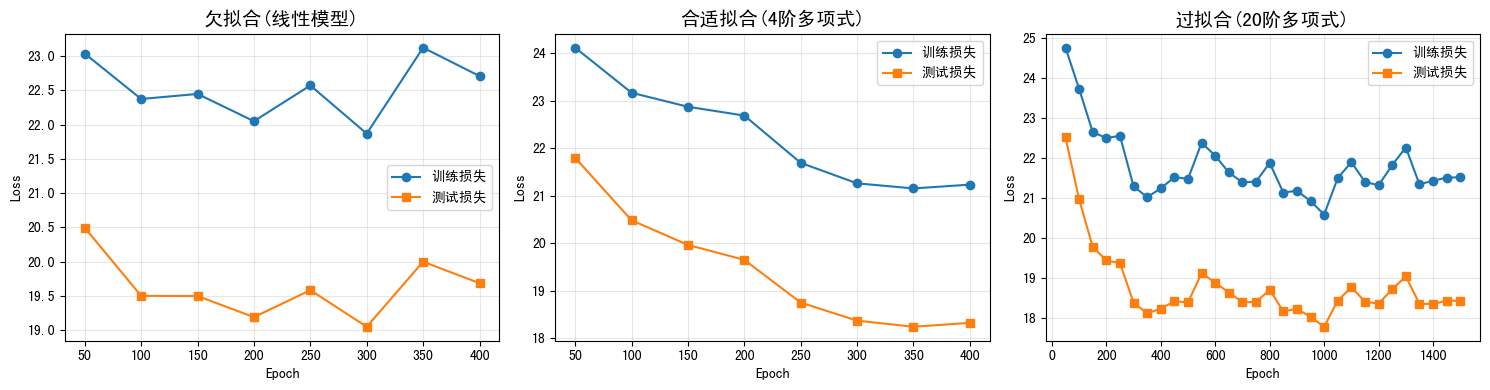

观察:
- 欠拟合: 训练和测试损失都很高
- 合适拟合: 训练和测试损失都低,且接近
- 过拟合: 训练损失很低,但测试损失很高(泛化差距大!)


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 欠拟合
epochs = range(50, 401, 50)
axes[0].plot(epochs, [l.detach().cpu().numpy() for l in train_losses_under], marker='o', label='训练损失')
axes[0].plot(epochs, [l.detach().cpu().numpy() for l in test_losses_under], marker='s', label='测试损失')
axes[0].set_title('欠拟合(线性模型)', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 合适拟合
axes[1].plot(epochs, [l.detach().cpu().numpy() for l in train_losses_fit], marker='o', label='训练损失')
axes[1].plot(epochs, [l.detach().cpu().numpy() for l in test_losses_fit], marker='s', label='测试损失')
axes[1].set_title('合适拟合(4阶多项式)', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 过拟合
epochs_over = range(50, 1501, 50)
axes[2].plot(epochs_over, [l.detach().cpu().numpy() for l in train_losses_over], marker='o', label='训练损失')
axes[2].plot(epochs_over, [l.detach().cpu().numpy() for l in test_losses_over], marker='s', label='测试损失')
axes[2].set_title('过拟合(20阶多项式)', fontsize=14)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('观察:')
print('- 欠拟合: 训练和测试损失都很高')
print('- 合适拟合: 训练和测试损失都低,且接近')
print('- 过拟合: 训练损失很低,但测试损失很高(泛化差距大!)')


---

## 第二部分: 权重衰减(L2正则化)

### 2.1 原理

**目标**: 限制模型复杂度,防止过拟合

**方法**: 在损失函数中加入权重的惩罚项

$$L_{\text{new}} = L_{\text{original}} + \frac{\lambda}{2} \|\mathbf{w}\|^2$$

其中:
- $\lambda$: 正则化系数(超参数)
- $\|\mathbf{w}\|^2 = \sum_i w_i^2$: 权重的L2范数平方

**效果**:
- 权重倾向于较小的值
- 模型更简单,泛化能力更强
- $\lambda$越大,正则化越强

### 2.2 从零开始实现

In [30]:
def l2_penalty(w):
    """L2惩罚项"""
    return torch.sum(w.pow(2)) / 2

In [31]:
# 生成数据
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05

train_data = torch.normal(0, 1, (n_train, num_inputs))
train_labels = torch.matmul(train_data, true_w) + true_b
train_labels += torch.normal(0, 0.01, size=train_labels.shape)

test_data = torch.normal(0, 1, (n_test, num_inputs))
test_labels = torch.matmul(test_data, true_w) + true_b
test_labels += torch.normal(0, 0.01, size=test_labels.shape)

print(f'训练数据: {train_data.shape}')
print(f'测试数据: {test_data.shape}')

训练数据: torch.Size([20, 200])
测试数据: torch.Size([100, 200])


In [32]:
def init_params():
    """初始化参数"""
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

def train_scratch(lambd):
    """从零开始训练,使用权重衰减"""
    w, b = init_params()
    net = lambda X: torch.matmul(X, w) + b
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003

    train_losses, test_losses = [], []

    for epoch in range(num_epochs):
        for X, y in torch.utils.data.DataLoader(
                torch.utils.data.TensorDataset(train_data, train_labels),
                batch_size, shuffle=True):
            # 损失 = MSE + λ/2 * ||w||²
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()

            # 手动SGD
            with torch.no_grad():
                w -= lr * w.grad / batch_size
                b -= lr * b.grad / batch_size
                w.grad.zero_()
                b.grad.zero_()

        if (epoch + 1) % 10 == 0:
            with torch.no_grad():
                train_l = loss(net(train_data), train_labels).mean()
                test_l = loss(net(test_data), test_labels).mean()
                train_losses.append(train_l)
                test_losses.append(test_l)
                print(f'epoch {epoch + 1}, train loss {train_l:.4f}, '
                      f'test loss {test_l:.4f}')

    print(f'w的L2范数: {torch.norm(w).item():.4f}')
    return train_losses, test_losses

**不使用权重衰减(λ=0)**

In [33]:
print('=== 不使用权重衰减 ===')
train_l_no_wd, test_l_no_wd = train_scratch(lambd=0)

=== 不使用权重衰减 ===
epoch 10, train loss 1.4468, test loss 177.3116
epoch 20, train loss 0.0434, test loss 176.0783
epoch 30, train loss 0.0018, test loss 175.9081
epoch 40, train loss 0.0001, test loss 175.8775
epoch 50, train loss 0.0000, test loss 175.8707
epoch 60, train loss 0.0000, test loss 175.8690
epoch 70, train loss 0.0000, test loss 175.8686
epoch 80, train loss 0.0000, test loss 175.8685
epoch 90, train loss 0.0000, test loss 175.8684
epoch 100, train loss 0.0000, test loss 175.8685
w的L2范数: 12.9728


**使用权重衰减(λ=3)**

In [34]:
print('\n=== 使用权重衰减 ===')
train_l_wd, test_l_wd = train_scratch(lambd=3)


=== 使用权重衰减 ===
epoch 10, train loss 1.2984, test loss 92.9444
epoch 20, train loss 0.0160, test loss 44.7229
epoch 30, train loss 0.0163, test loss 22.0641
epoch 40, train loss 0.0164, test loss 11.0943
epoch 50, train loss 0.0157, test loss 5.7628
epoch 60, train loss 0.0146, test loss 3.1579
epoch 70, train loss 0.0138, test loss 1.8759
epoch 80, train loss 0.0128, test loss 1.2343
epoch 90, train loss 0.0122, test loss 0.9037
epoch 100, train loss 0.0112, test loss 0.7245
w的L2范数: 0.4662


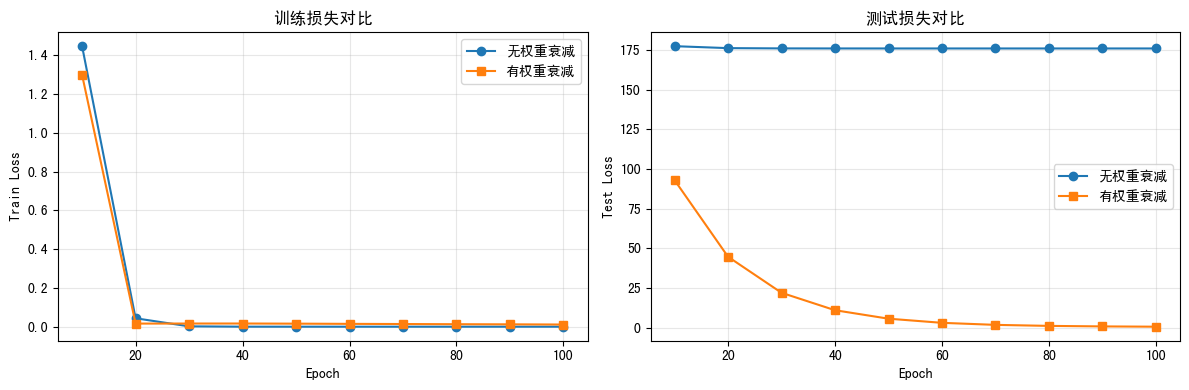

观察: 权重衰减提高了测试性能(泛化能力)!


In [35]:
# 可视化对比
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(10, 101, 10)

# 训练损失
ax1.plot(epochs, train_l_no_wd, marker='o', label='无权重衰减')
ax1.plot(epochs, train_l_wd, marker='s', label='有权重衰减')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Train Loss')
ax1.set_title('训练损失对比')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 测试损失
ax2.plot(epochs, test_l_no_wd, marker='o', label='无权重衰减')
ax2.plot(epochs, test_l_wd, marker='s', label='有权重衰减')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Test Loss')
ax2.set_title('测试损失对比')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('观察: 权重衰减提高了测试性能(泛化能力)!')

### 2.3 PyTorch简洁实现

PyTorch的优化器自带`weight_decay`参数

In [36]:
def train_concise(wd):
    """使用PyTorch的weight_decay"""
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()

    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003

    # weight_decay参数就是λ
    trainer = torch.optim.SGD([{"params": net[0].weight, 'weight_decay': wd},
                                {"params": net[0].bias}], lr=lr)

    train_losses, test_losses = [], []

    for epoch in range(num_epochs):
        for X, y in torch.utils.data.DataLoader(
                torch.utils.data.TensorDataset(train_data, train_labels),
                batch_size, shuffle=True):
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()

        if (epoch + 1) % 10 == 0:
            train_l = loss(net(train_data), train_labels).mean()
            test_l = loss(net(test_data), test_labels).mean()
            train_losses.append(train_l.item())
            test_losses.append(test_l.item())

    print(f'w的L2范数: {net[0].weight.norm().item():.4f}')
    return train_losses, test_losses

print('=== PyTorch简洁实现(有权重衰减) ===')
train_l_concise, test_l_concise = train_concise(wd=3)
print(f'最终测试损失: {test_l_concise[-1]:.4f}')

=== PyTorch简洁实现(有权重衰减) ===
w的L2范数: 0.4664
最终测试损失: 1.1988


---

## 第三部分: Dropout暂退法

### 3.1 原理

**核心思想**: 在训练时随机"丢弃"一些神经元

**工作机制**:
1. 训练时: 每个神经元以概率$p$被置为0
2. 训练时: 保留的神经元输出乘以$\frac{1}{1-p}$(保持期望不变)
3. 测试时: 使用所有神经元,不做dropout

**为什么有效?**
- 防止神经元"共适应"(co-adaptation)
- 相当于训练多个子网络的集成
- 强制学习更鲁棒的特征

### 3.2 从零开始实现

In [37]:
def dropout_layer(X, dropout):
    """Dropout层"""
    assert 0 <= dropout <= 1

    # dropout=1: 全部丢弃
    if dropout == 1:
        return torch.zeros_like(X)

    # dropout=0: 不丢弃
    if dropout == 0:
        return X

    # 生成mask: 1表示保留, 0表示丢弃
    mask = (torch.rand(X.shape) > dropout).float()

    # 保持期望不变
    return mask * X / (1.0 - dropout)

# 测试dropout
X_test = torch.arange(16, dtype=torch.float32).reshape((2, 8))
print('原始输入:')
print(X_test)
print('\nDropout=0.0 (不丢弃):')
print(dropout_layer(X_test, 0.0))
print('\nDropout=0.5 (丢弃50%):')
print(dropout_layer(X_test, 0.5))
print('\nDropout=1.0 (全部丢弃):')
print(dropout_layer(X_test, 1.0))

原始输入:
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])

Dropout=0.0 (不丢弃):
tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])

Dropout=0.5 (丢弃50%):
tensor([[ 0.,  2.,  4.,  0.,  0., 10.,  0., 14.],
        [16.,  0., 20., 22., 24.,  0.,  0.,  0.]])

Dropout=1.0 (全部丢弃):
tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


### 3.3 Fashion-MNIST上应用Dropout

In [38]:
import torchvision
from torch.utils import data
from torchvision import transforms

# 加载数据
batch_size = 256
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root=datasets_dir, train=True, transform=trans, download=True)
mnist_test = torchvision.datasets.FashionMNIST(
    root=datasets_dir, train=False, transform=trans, download=True)

train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True, num_workers=4)
test_iter = data.DataLoader(mnist_test, batch_size, shuffle=False, num_workers=4)

In [39]:
# 定义模型参数
num_inputs, num_outputs, num_hiddens1, num_hiddens2 = 784, 10, 256, 256

dropout1, dropout2 = 0.2, 0.5

class Net(nn.Module):
    def __init__(self, num_inputs, num_outputs, num_hiddens1, num_hiddens2,
                 is_training=True):
        super(Net, self).__init__()
        self.num_inputs = num_inputs
        self.training = is_training

        self.lin1 = nn.Linear(num_inputs, num_hiddens1)
        self.lin2 = nn.Linear(num_hiddens1, num_hiddens2)
        self.lin3 = nn.Linear(num_hiddens2, num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((-1, self.num_inputs))))
        # 只在训练时使用dropout
        if self.training:
            H1 = dropout_layer(H1, dropout1)

        H2 = self.relu(self.lin2(H1))
        if self.training:
            H2 = dropout_layer(H2, dropout2)

        out = self.lin3(H2)
        return out

net = Net(num_inputs, num_outputs, num_hiddens1, num_hiddens2)
print(net)

Net(
  (lin1): Linear(in_features=784, out_features=256, bias=True)
  (lin2): Linear(in_features=256, out_features=256, bias=True)
  (lin3): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
)


In [40]:
# 训练函数
def accuracy(y_hat, y):
    """计算预测正确的数量"""
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def evaluate_accuracy(net, data_iter):
    """计算准确率"""
    net.eval()  # 设置为评估模式
    metric = [0.0, 0.0]
    with torch.no_grad():
        for X, y in data_iter:
            metric[0] += accuracy(net(X), y)
            metric[1] += y.numel()
    net.train()  # 恢复训练模式
    return metric[0] / metric[1]

def train_dropout(net, train_iter, test_iter, num_epochs, lr):
    """训练模型"""
    loss = nn.CrossEntropyLoss(reduction='mean')
    trainer = torch.optim.SGD(net.parameters(), lr=lr)

    train_losses, train_accs, test_accs = [], [], []

    for epoch in range(num_epochs):
        net.train()
        metric = [0.0, 0.0, 0.0]

        for X, y in train_iter:
            trainer.zero_grad()
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            trainer.step()

            metric[0] += float(l * y.numel())
            metric[1] += float(accuracy(y_hat, y))
            metric[2] += y.numel()

        train_loss = metric[0] / metric[2]
        train_acc = metric[1] / metric[2]
        test_acc = evaluate_accuracy(net, test_iter)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        print(f'epoch {epoch + 1}, loss {train_loss:.3f}, '
              f'train acc {train_acc:.3f}, test acc {test_acc:.3f}')

    return train_losses, train_accs, test_accs

# 训练
num_epochs, lr = 10, 0.5
train_losses, train_accs, test_accs = train_dropout(
    net, train_iter, test_iter, num_epochs, lr)

epoch 1, loss 0.897, train acc 0.669, test acc 0.804
epoch 2, loss 0.529, train acc 0.805, test acc 0.787
epoch 3, loss 0.462, train acc 0.831, test acc 0.835
epoch 4, loss 0.425, train acc 0.844, test acc 0.847
epoch 5, loss 0.402, train acc 0.852, test acc 0.859
epoch 6, loss 0.380, train acc 0.862, test acc 0.863
epoch 7, loss 0.366, train acc 0.866, test acc 0.865
epoch 8, loss 0.356, train acc 0.869, test acc 0.767
epoch 9, loss 0.344, train acc 0.873, test acc 0.860
epoch 10, loss 0.333, train acc 0.877, test acc 0.836


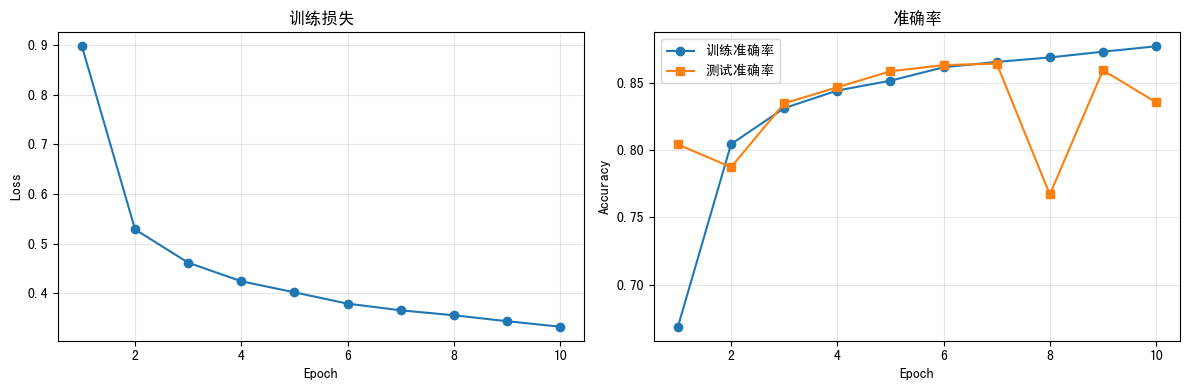


最终测试准确率: 83.57%


In [41]:
# 可视化
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, num_epochs + 1)

ax1.plot(epochs, train_losses, marker='o')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('训练损失')
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, train_accs, marker='o', label='训练准确率')
ax2.plot(epochs, test_accs, marker='s', label='测试准确率')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('准确率')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n最终测试准确率: {test_accs[-1]:.2%}')

### 3.4 PyTorch简洁实现

In [42]:
net_concise = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Dropout(dropout1),  # 第一个dropout层
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Dropout(dropout2),  # 第二个dropout层
    nn.Linear(256, 10)
)

def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.normal_(m.weight, std=0.01)

net_concise.apply(init_weights)

print('模型结构:')
print(net_concise)

模型结构:
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.2, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): ReLU()
  (6): Dropout(p=0.5, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)


In [43]:
# 训练简洁版
trainer_concise = torch.optim.SGD(net_concise.parameters(), lr=0.5)
train_losses_c, train_accs_c, test_accs_c = train_dropout(
    net_concise, train_iter, test_iter, num_epochs, lr)

print(f'\n简洁实现 - 最终测试准确率: {test_accs_c[-1]:.2%}')

epoch 1, loss 1.153, train acc 0.554, test acc 0.671
epoch 2, loss 0.588, train acc 0.782, test acc 0.767
epoch 3, loss 0.490, train acc 0.821, test acc 0.838
epoch 4, loss 0.450, train acc 0.835, test acc 0.825
epoch 5, loss 0.420, train acc 0.847, test acc 0.844
epoch 6, loss 0.398, train acc 0.855, test acc 0.843
epoch 7, loss 0.382, train acc 0.860, test acc 0.858
epoch 8, loss 0.369, train acc 0.866, test acc 0.850
epoch 9, loss 0.357, train acc 0.868, test acc 0.832
epoch 10, loss 0.346, train acc 0.874, test acc 0.869

简洁实现 - 最终测试准确率: 86.89%


---

## 第四部分: 数值稳定性与参数初始化

### 4.1 梯度消失与梯度爆炸

**梯度消失**: 梯度变得非常小,前面的层几乎不更新
**梯度爆炸**: 梯度变得非常大,参数更新剧烈

**原因**:
- 深层网络中梯度需要连续相乘
- 如果每层的梯度 < 1 → 指数衰减(消失)
- 如果每层的梯度 > 1 → 指数增长(爆炸)

### 4.2 参数初始化方法

**默认初始化(不好)**:
```python
W = torch.zeros(...)  # 所有权重相同,对称性问题
```

**随机初始化(基础)**:
```python
W = torch.normal(0, 0.01, ...)  # 标准差固定
```

**Xavier初始化**(适合Sigmoid/Tanh):
$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}} + n_{\text{out}}}}\right)$$

**He初始化**(适合ReLU):
$$W \sim \mathcal{N}\left(0, \sqrt{\frac{2}{n_{\text{in}}}}\right)$$

### 4.3 实验对比

In [ ]:
# 比较不同初始化方法
def compare_initializations():
    """比较不同的权重初始化"""
    results = {}

    # 1. 默认初始化(标准差0.01)
    net1 = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )
    for param in net1.parameters():
        if len(param.shape) >= 2:
            nn.init.normal_(param, std=0.01)

    # 2. Xavier初始化
    net2 = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )
    for param in net2.parameters():
        if len(param.shape) >= 2:
            nn.init.xavier_uniform_(param)

    # 3. He初始化
    net3 = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784, 256),
        nn.ReLU(),
        nn.Linear(256, 10)
    )
    for param in net3.parameters():
        if len(param.shape) >= 2:
            nn.init.kaiming_uniform_(param)

    # 简单训练几个epoch
    for name, net in [('Normal(0,0.01)', net1), ('Xavier', net2), ('He', net3)]:
        print(f'\n训练使用{name}初始化的模型...')
        trainer = torch.optim.SGD(net.parameters(), lr=0.1)

        for epoch in range(3):
            for X, y in train_iter:
                trainer.zero_grad()
                l = nn.CrossEntropyLoss()(net(X), y)
                l.backward()
                trainer.step()

        test_acc = evaluate_accuracy(net, test_iter)
        print(f'{name}初始化 - 3 epoch后测试准确率: {test_acc:.3f}')
        results[name] = test_acc

    return results

results = compare_initializations()

print('\n=== 初始化方法对比 ===')
for name, acc in results.items():
    print(f'{name}: {acc:.2%}')

---

## 小结

### 过拟合与欠拟合

| 问题 | 训练误差 | 测试误差 | 原因 | 解决方案 |
|------|---------|---------|------|----------|
| 欠拟合 | 高 | 高 | 模型太简单 | 增加模型复杂度 |
| 合适 | 低 | 低 | 刚刚好 | - |
| 过拟合 | 很低 | 高 | 模型太复杂 | 正则化 |

### 正则化技术

1. **权重衰减(L2正则化)**:
   - 在损失函数中加入$\frac{\lambda}{2}\|\mathbf{w}\|^2$
   - 限制权重大小,简化模型
   - PyTorch: `optimizer(..., weight_decay=λ)`

2. **Dropout**:
   - 训练时随机丢弃神经元
   - 防止共适应,相当于模型集成
   - PyTorch: `nn.Dropout(p)`

3. **其他方法**:
   - 数据增强
   - 早停(Early Stopping)
   - Batch Normalization

### 参数初始化

- **Xavier**: 适合Sigmoid/Tanh
- **He**: 适合ReLU
- 防止梯度消失/爆炸

### 关键要点

- ✅ 过拟合是深度学习的核心挑战
- ✅ 正则化是对抗过拟合的关键武器
- ✅ Dropout是深度神经网络的标配
- ✅ 合适的初始化对训练至关重要
- ✅ 始终监控训练误差和测试误差的差距

## 练习

1. **调整dropout概率**: 尝试0.1, 0.3, 0.7,观察对性能的影响
2. **权重衰减系数**: 测试λ=0.001, 0.01, 0.1, 1.0
3. **组合使用**: 同时使用权重衰减和Dropout
4. **数据增强**: 对图像进行随机翻转、旋转
5. **早停**: 实现早停机制(当验证误差不再下降时停止训练)
6. **L1正则化**: 实现L1正则化(Lasso)
7. **不同激活函数**: 对比ReLU, Sigmoid, Tanh下的梯度消失
8. **可视化**: 绘制不同epoch下的决策边界